<a href="https://colab.research.google.com/github/FlorenciaSosa706/Entrenamiento-CNN-/blob/main/Entrenamiento_CNN_Perros_VS_Gatos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TensorFlow version: 2.19.0


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.T3D3PL_4.0.1/cats_vs_dogs-train.tfrecord*...:   0%…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.


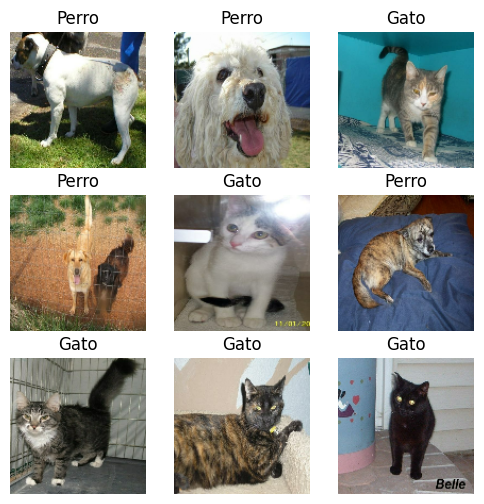

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 625s 1s/step - accuracy: 0.6468 - loss: 0.6221 - val_accuracy: 0.7198 - val_loss: 0.5486
Epoch 2/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 611s 1s/step - accuracy: 0.7593 - loss: 0.5003 - val_accuracy: 0.7862 - val_loss: 0.4476
Epoch 3/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 599s 1s/step - accuracy: 0.7987 - loss: 0.4358 - val_accuracy: 0.8180 - val_loss: 0.4026
Epoch 4/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 615s 1s/step - accuracy: 0.8387 - loss: 0.3667 - val_accuracy: 0.8384 - val_loss: 0.3747
Epoch 5/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 622s 1s/step - accuracy: 0.8663 - loss: 0.3092 - val_accuracy: 0.8427 - val_loss: 0.3601


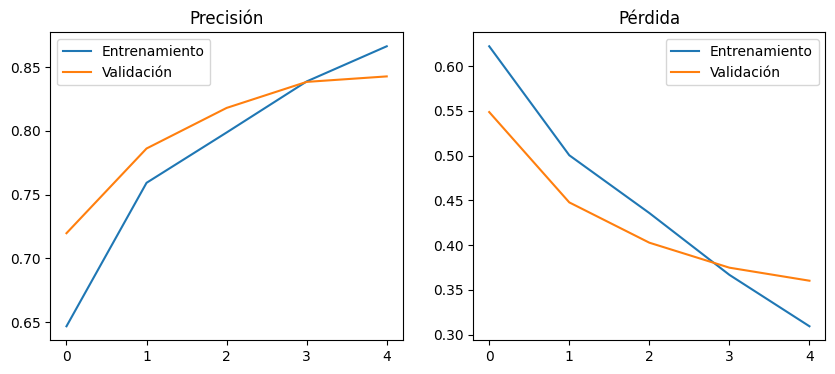

Entrenamiento completado y modelo guardado.


In [ ]:
# ================================================
# ENTRENAMIENTO CNN: CLASIFICACIÓN PERROS VS GATOS
# ================================================

# Paso 1: Importar librerías
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

# Verificar versión
print("TensorFlow version:", tf.__version__)

# Paso 2: Cargar dataset desde TensorFlow Datasets
# (Se descarga automáticamente en Colab)
dataset, info = tfds.load('cats_vs_dogs', with_info=True, as_supervised=True)

train_data, test_data = dataset['train'], dataset['train']  # No hay split predefinido
# Vamos a dividir manualmente
train_size = 0.8
train_data = train_data.take(int(info.splits['train'].num_examples * train_size))
val_data = dataset['train'].skip(int(info.splits['train'].num_examples * train_size))

# Paso 3: Preprocesamiento (redimensionar y normalizar)
IMG_SIZE = 128

def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = image / 255.0
    return image, label

train_data = train_data.map(preprocess).shuffle(1000).batch(32).prefetch(tf.data.AUTOTUNE)
val_data = val_data.map(preprocess).batch(32).prefetch(tf.data.AUTOTUNE)

# Paso 4: Visualizar algunas imágenes
for image, label in train_data.take(1):
    plt.figure(figsize=(6,6))
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(image[i])
        plt.title("Gato" if label[i].numpy() == 0 else "Perro")
        plt.axis("off")
    plt.show()

# Paso 5: Definir la arquitectura de la CNN
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')  # salida binaria
])

model.summary()

# Paso 6: Compilar el modelo
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Paso 7: Entrenar el modelo
EPOCHS = 5
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS
)

# Paso 8: Evaluar desempeño
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.legend()
plt.title('Precisión')

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.legend()
plt.title('Pérdida')
plt.show()

# Paso 9: Guardar modelo (opcional)
model.save("modelo_perros_vs_gatos.h5")
print("Entrenamiento completado y modelo guardado.")
